**TASK 4: Predicting Insurance Claim Amounts**

**STEP 1: IMPORT LIBRARIES**

In [1]:
# Import libraries (run first)

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

**STEP 2: LOAD DATASET**

In [2]:
# Load dataset from online source

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**STEP 3: UNDERSTAND DATA**

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**STEP 4: EDA**

**Age vs Charges**

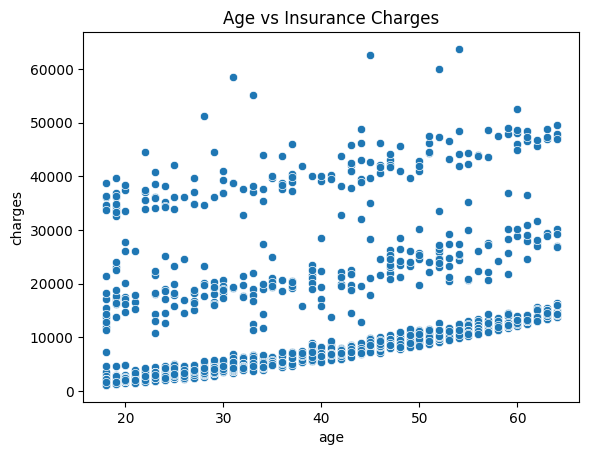

In [5]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

**BMI vs Charges**

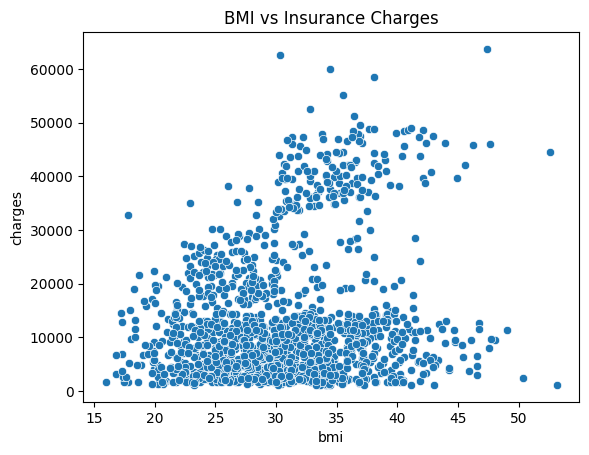

In [6]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

**Smoking Impact**

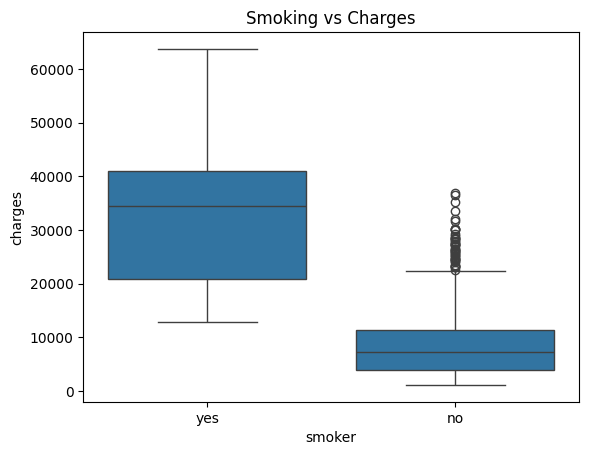

In [7]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking vs Charges")
plt.show()

**STEP 5: ENCODE CATEGORICAL DATA**

In [8]:
# Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)

**STEP 6: DEFINE FEATURES & TARGET**

In [9]:
# Target variable
y = df['charges']

In [10]:
# Features
X = df.drop('charges', axis=1)

**STEP 7: SPLIT DATA**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**STEP 8: TRAIN MODEL (LINEAR REGRESSION)**

In [12]:
# Create model
model = LinearRegression()

In [13]:
# Train model
model.fit(X_train, y_train)

LinearRegression()

**STEP 9: PREDICTION**

In [14]:
# Predict values
y_pred = model.predict(X_test)

**STEP 10: EVALUATION**

In [15]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4181.19447375365


RMSE (Root Mean Squared Error)

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5796.284659276273


**STEP 11: ACTUAL vs PREDICTED GRAPH**

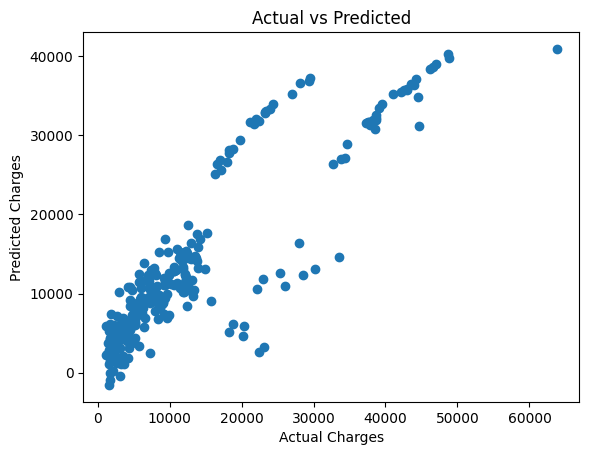

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

**STEP 12: CONCLUSION**


# - Smoking has the strongest impact on insurance charges
# - Age and BMI also influence costs
# - Linear Regression provides reasonable predictions
# - Model performance evaluated using MAE and RMSE